In [56]:
from dotenv import load_dotenv
load_dotenv()

True

In [57]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

llm = ChatOpenAI(model="gpt-4.1", temperature=0)
small_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = PineconeVectorStore(
    index_name="inhouse-python-index",
    embedding=embeddings,
)

retriever = vector_store.as_retriever()


In [58]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langchain_core.documents import Document


class AgentState(TypedDict):
    question: str
    answer: str
    context: list[Document]
    document_name: str
    is_in_faq: bool
    
graph_builder = StateGraph(AgentState)

In [59]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def check_faq(state: AgentState) -> AgentState:
  question = state['question']
  context = retriever.invoke(question, filter={"source":"employee_benefits_and_welfare_faq"})
  check_faq_prompt = ChatPromptTemplate.from_messages([
    ("system","""You are a helpful assistant that checks if the question is in the FAQ. 
     If the question is in the FAQ, return 'Yes'. Otherwise, return 'No'."""),
    ("user","Question: {question}\nContext:{context}"),
  ])  
  
  check_faq_chain = check_faq_prompt | llm | StrOutputParser()
  is_in_faq = check_faq_chain.invoke({"question":question,"context":context})
  return {"is_in_faq": is_in_faq == "Yes","context":context}

In [60]:
def get_document_name(state: AgentState) -> AgentState:
    determine_document_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """You are a helpful assistant that determines the most relevant document name based on the user's question. 
Choose from the following document names:
- delegation_of_authority
- employee_benefits_and_welfare_faq
- employee_benefits_and_welfare_guide
- employee_handbook_and_hr_policy
- expense_management_guide
- it_support_guide
- legal_and_compliance_policy

Return ONLY the document name (e.g., 'it_support_guide').

Examples:
- If the question is about who can approve expenses, return 'delegation_of_authority' or 'expense_management_guide' as appropriate.
- If the question is about employee benefits, return 'employee_benefits_and_welfare_guide'.
- If the question is about HR policies or the employee handbook, return 'employee_handbook_and_hr_policy'.
- If the question is about IT support or technical issues, return 'it_support_guide'.
- If the question is about legal or compliance matters, return 'legal_and_compliance_policy'.
- If the question is a frequently asked question about benefits, return 'employee_benefits_and_welfare_faq'.
"""),
        ("user", "Question: {question}"),
    ]
)
    question = state['question']
    determine_document_chain = determine_document_prompt | llm | StrOutputParser()
    document_name = determine_document_chain.invoke({"question": question})
    return {"document_name": document_name}

In [61]:
def retrieve_document(state: AgentState) -> AgentState:
    question = state['question']
    document_name = state['document_name']
    context = retriever.invoke(question, filter={"source": document_name})
    return {"context": context}

In [62]:
def generate_answer(state: AgentState) -> AgentState:
    question = state['question']
    context = state['context']
    generate_answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant that generates an answer to the user's question based on the context.
        """),
        ("user", "Question: {question}\nContext: {context}"),
    ])
    generate_answer_chain = generate_answer_prompt | llm | StrOutputParser()
    answer = generate_answer_chain.invoke({"question": question, "context": context})
    return {"answer": answer}

In [63]:
from typing import Literal

def check_if_in_faq(state: AgentState) -> Literal["generate_answer", "get_document_name"]:
    is_in_faq = state['is_in_faq']
    if is_in_faq:
        return "generate_answer"
    else:
        return "get_document_name"

In [64]:
from langgraph.graph import START, END

graph_builder.add_node(check_faq)
graph_builder.add_node(get_document_name)
graph_builder.add_node(retrieve_document)
graph_builder.add_node(generate_answer)

graph_builder.add_edge(START, "check_faq")
graph_builder.add_conditional_edges("check_faq", check_if_in_faq)
graph_builder.add_edge("get_document_name", "retrieve_document")
graph_builder.add_edge("retrieve_document", "generate_answer")
graph_builder.add_edge("generate_answer", END)

graph = graph_builder.compile()

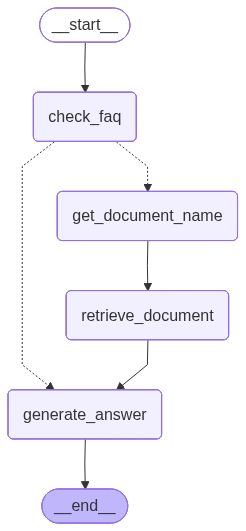

In [65]:
graph

In [67]:
graph.invoke({"question":"출산휴가는 얼마나 보장되나요?"})

{'question': '출산휴가는 얼마나 보장되나요?',
 'answer': '출산휴가는 얼마나 보장되나요?\n\n제공된 정보에 따르면, 출산휴가는 출산 예정일 전후로 자유롭게 사용할 수 있으며, 최대 20일 유급으로 보장됩니다. 즉, 출산 전이나 후에 본인의 상황에 맞게 사용할 수 있고, 이 기간 동안 급여도 정상적으로 지급됩니다.',
 'context': [Document(id='4fd5db88-641f-41e9-9903-c7910e075dfd', metadata={'source': 'employee_benefits_and_welfare_faq'}, page_content='직원 복리후생 및 복지 FAQ\n======================  \n1. 연차 유급 휴가 관련\n------------------  \nQ1: 연차 휴가는 어떻게 사용하나요?\n* A: 연차 휴가는 본인 승인을 통해 자유롭게 사용할 수 있으며, 사내 HR 시스템에서 신청 가능합니다.  \nQ2: 연차는 어떻게 계산되나요?\n* A: 근속 연수에 따라 차등 지급되며, 1년 미만은 월 1일, 1~3년은 15일, 10년 이상은 20일입니다.  \nQ3: 미사용 연차는 어떻게 처리되나요?\n* A: 연차는 해당 연도에 사용해야 하며, 이월은 불가합니다.  \n2. 출산 및 육아 휴가 관련\n---------------------  \nQ4: 출산 휴가는 언제부터 사용할 수 있나요?\n* A: 출산 예정일 전후로 자유롭게 사용할 수 있으며, 최대 20일 유급으로 제공됩니다.  \nQ5: 육아 휴가는 누구에게 적용되나요?\n* A: 모든 직원이 신청할 수 있으며, 최대 1년까지 사용할 수 있으며, 첫 3개월은 급여의 50%가 지급됩니다.  \n3. 경조 휴가 및 지원\n-----------------  \nQ6: 경조 휴가는 어떤 경우에 사용할 수 있나요?\n* A: 본인 결혼, 자녀 출생, 부모/배우자 사망 등 경조사 사유에 따라 휴가가 부여됩니다.  \nQ7: 경조사 지원금은 어떻